# Skating Power & Stamina Analysis
Calculate top speed from tracking data and analyze how it changes throughout the game to detect fatigue patterns.

*Note*: This was early analysis that inspired my final models in the stamina_models folder

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

tracking = pd.read_parquet('../data/tracking.parquet')
shifts = pd.read_parquet('../data/shifts.parquet')

skaters = tracking[tracking['Player or Puck'] == 'Player'].copy()
skaters['Game'] = skaters['Image Id'].str.extract(r'(^\d{4}-\d{2}-\d{2}.*?)_')[0]
skaters = skaters.sort_values(['Game', 'Period', 'Player Jersey Number', 'Image Id']).reset_index(drop=True)

skaters['x_smooth'] = skaters.groupby(['Game', 'Period', 'Player Jersey Number'])['x'].transform(
    lambda x: x.rolling(window=5, min_periods=1, center=True).mean()
)
skaters['y_smooth'] = skaters.groupby(['Game', 'Period', 'Player Jersey Number'])['y'].transform(
    lambda x: x.rolling(window=5, min_periods=1, center=True).mean()
)

skaters['x_prev'] = skaters.groupby(['Game', 'Period', 'Player Jersey Number'])['x_smooth'].shift(1)
skaters['y_prev'] = skaters.groupby(['Game', 'Period', 'Player Jersey Number'])['y_smooth'].shift(1)

skaters['image_num'] = skaters['Image Id'].str.extract(r'_(\d+)$')[0].astype(float)
skaters['image_prev'] = skaters.groupby(['Game', 'Period', 'Player Jersey Number'])['image_num'].shift(1)
skaters['frame_diff'] = skaters['image_num'] - skaters['image_prev']

skaters['distance'] = np.sqrt(
    (skaters['x_smooth'] - skaters['x_prev'])**2 + 
    (skaters['y_smooth'] - skaters['y_prev'])**2
)

skaters['speed_mph'] = np.where(
    skaters['frame_diff'] == 1,
    skaters['distance'] * 30 * 0.681818,
    np.nan
)

skaters['speed_mph'] = np.where(
    (skaters['speed_mph'] > 30) | (skaters['speed_mph'] < 0),
    np.nan,
    skaters['speed_mph']
)

print(f"Skaters dataframe: {len(skaters):,} rows")
print(f"Valid speed measurements: {skaters['speed_mph'].notna().sum():,}")
print(f"\nSpeed statistics (mph):")
print(skaters['speed_mph'].describe())

Skaters dataframe: 7,441,848 rows
Valid speed measurements: 6,958,119

Speed statistics (mph):
count    6.958119e+06
mean     9.174751e+00
std      5.278991e+00
min      0.000000e+00
25%      4.752989e+00
50%      9.211009e+00
75%      1.310411e+01
max      2.999937e+01
Name: speed_mph, dtype: float64


2025-11-02 Team D @ Team A
39


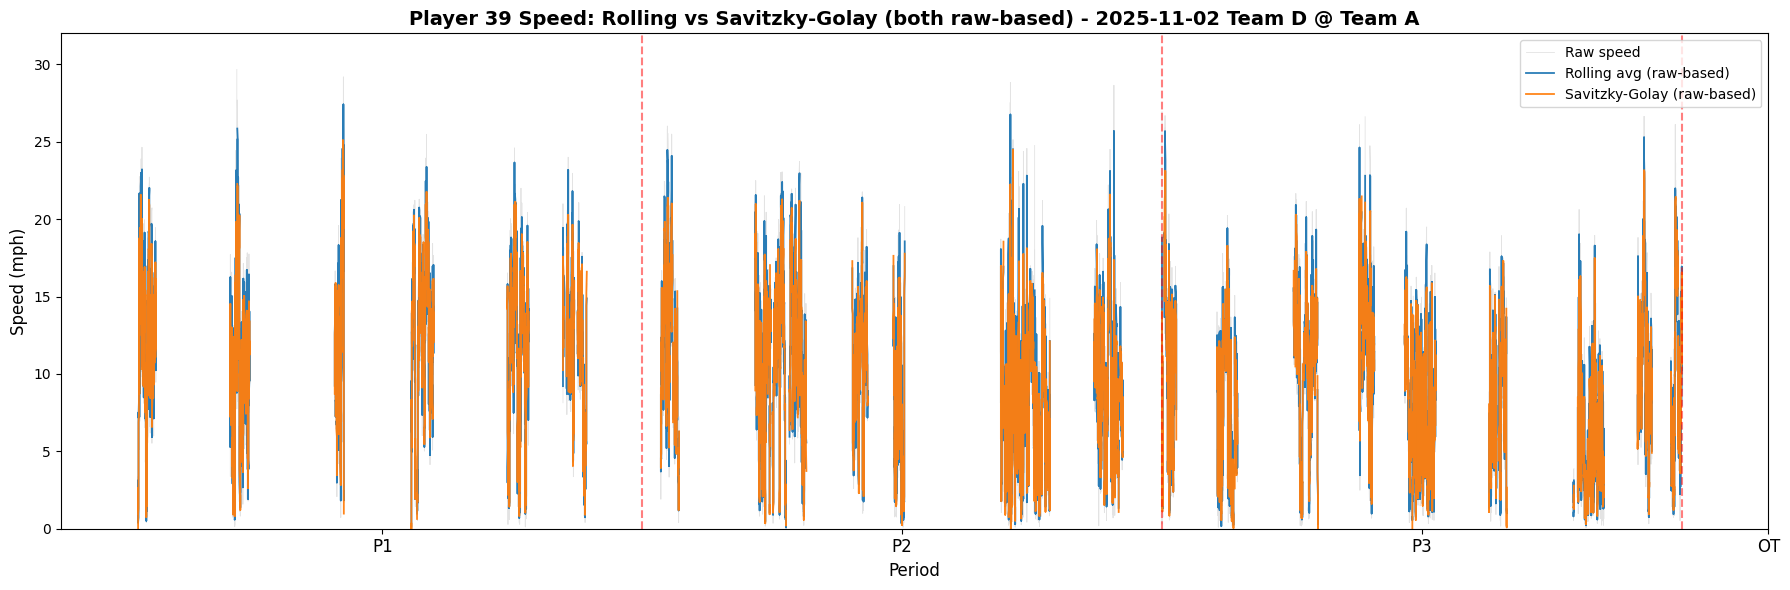

In [9]:
from scipy.signal import savgol_filter

def clock_to_seconds(clock_str, period):
    if pd.isna(clock_str):
        return np.nan
    parts = str(clock_str).split(':')
    minutes = int(parts[0])
    seconds = int(parts[1])
    clock_seconds = minutes * 60 + seconds

    if period == 'OT':
        return 3600 + (300 - clock_seconds)
    else:
        period_int = int(period)
        return (period_int - 1) * 1200 + (1200 - clock_seconds)

sample_game = skaters['Game'].value_counts().index[3]
sample_player = skaters[skaters['Game'] == sample_game]['Player Jersey Number'].value_counts().index[5]
print(sample_game)
print(sample_player)

player_data = skaters[(skaters['Game'] == sample_game) & (skaters['Player Jersey Number'] == sample_player)].copy()
player_data['game_seconds'] = player_data.apply(lambda row: clock_to_seconds(row['Game Clock'], row['Period']), axis=1)
player_data = player_data.sort_values(['Period', 'image_num']).reset_index(drop=True)

# Segment by continuous frame runs so we never smooth across shift gaps
player_data['img_gap'] = player_data['image_num'].diff()
player_data['segment_id'] = (player_data['img_gap'] != 1).cumsum()

# Build speed from raw coordinates (no coordinate rolling-average)
player_data['x_raw_prev'] = player_data['x'].shift(1)
player_data['y_raw_prev'] = player_data['y'].shift(1)
player_data['distance_raw'] = np.sqrt(
    (player_data['x'] - player_data['x_raw_prev'])**2 +
    (player_data['y'] - player_data['y_raw_prev'])**2
)
player_data['speed_raw_mph'] = np.where(
    player_data['img_gap'] == 1,
    player_data['distance_raw'] * 30 * 0.681818,
    np.nan
)
player_data['speed_raw_mph'] = np.where(
    (player_data['speed_raw_mph'] > 30) | (player_data['speed_raw_mph'] < 0),
    np.nan,
    player_data['speed_raw_mph']
)

# Rolling-average smoothing applied to raw speed
player_data['speed_roll_mph'] = np.nan

# Savitzky-Golay smoothing applied to raw speed
player_data['speed_savgol_raw'] = np.nan

for _, seg in player_data.groupby('segment_id'):
    valid_idx = seg.index[seg['speed_raw_mph'].notna()]
    n = len(valid_idx)

    if n == 0:
        continue

    # Rolling-average on raw speed
    roll_vals = player_data.loc[valid_idx, 'speed_raw_mph'].rolling(window=5, min_periods=1, center=True).mean()
    player_data.loc[valid_idx, 'speed_roll_mph'] = roll_vals.to_numpy()

    # Savitzky-Golay on raw speed
    if n < 5:
        player_data.loc[valid_idx, 'speed_savgol_raw'] = player_data.loc[valid_idx, 'speed_raw_mph']
        continue

    window = min(21, n if n % 2 == 1 else n - 1)
    if window < 5:
        player_data.loc[valid_idx, 'speed_savgol_raw'] = player_data.loc[valid_idx, 'speed_raw_mph']
        continue

    sg_vals = savgol_filter(
        player_data.loc[valid_idx, 'speed_raw_mph'].to_numpy(),
        window_length=window,
        polyorder=2,
        mode='interp'
    )
    player_data.loc[valid_idx, 'speed_savgol_raw'] = sg_vals

plt.figure(figsize=(18, 6))
plt.plot(player_data['game_seconds'], player_data['speed_raw_mph'], linewidth=0.6, alpha=0.22, color='gray', label='Raw speed')
plt.plot(player_data['game_seconds'], player_data['speed_roll_mph'], linewidth=1.3, alpha=0.95, color='tab:blue', label='Rolling avg (raw-based)')
plt.plot(player_data['game_seconds'], player_data['speed_savgol_raw'], linewidth=1.3, alpha=0.95, color='tab:orange', label='Savitzky-Golay (raw-based)')

plt.axvline(x=1200, color='red', linestyle='--', alpha=0.5, linewidth=1.5)
plt.axvline(x=2400, color='red', linestyle='--', alpha=0.5, linewidth=1.5)
plt.axvline(x=3600, color='red', linestyle='--', alpha=0.5, linewidth=1.5)

max_seconds = player_data['game_seconds'].max()
if max_seconds > 3600:
    plt.axvspan(3600, max_seconds + 100, alpha=0.08, color='grey')

ax = plt.gca()
ax.set_xticks([600, 1800, 3000, 3800])
ax.set_xticklabels(['P1', 'P2', 'P3', 'OT'], fontsize=12)

plt.xlabel('Period', fontsize=12)
plt.ylabel('Speed (mph)', fontsize=12)
plt.title(f'Player {sample_player} Speed: Rolling vs Savitzky-Golay (both raw-based) - {sample_game}', fontsize=14, fontweight='bold')
plt.ylim(0, 32)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()